# Assignment 4 — Dataset 3: CIFAR-10 (image)

**The third dataset, and the one where the small CNN starts to struggle.**

| # | Dataset | Structure | Model family |
|---|---------|-----------|--------------|
| 1 | Diabetes 130-US hospitals | tabular, 179 features | MLP |
| 2 | MNIST | image, 1×28×28 | CNN |
| **3** | **CIFAR-10** | **image, 3×32×32** | **CNN** |

### Why a second image dataset

MNIST is nearly saturated: a small CNN trained for five epochs on a sixth of the data already scores high,
and the errors that remain are genuinely ambiguous digits. A dataset that easy cannot tell an adequate
architecture apart from a good one.

CIFAR-10 changes three things at once:

- **Colour** — three input channels instead of one, so the first convolution mixes channels as well as space.
- **Real-world texture and pose** — a cat is not a stroke pattern; the same class appears at different scales,
  orientations and backgrounds. Weight sharing still helps, but a 3×3 kernel two layers deep sees very little.
- **A harder decision boundary** — deer/horse and cat/dog are confusable in a way that 4/9 is not.

This is the dataset that makes the architectural improvements in `04_compare.ipynb` — BatchNorm, residual
connections, attention — worth measuring. On MNIST they would all tie.

Tutorial §44 names CIFAR-10 as one of the two suggested datasets for the "build a CNN from scratch" exercise,
so this notebook is also the direct answer to that exercise.

In [1]:
import os, sys, json, platform

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import tensorflow as tf
import keras

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

print("torch     ", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

torch      2.10.0+cu130 | device: cuda | NVIDIA GeForce RTX 3060 Laptop GPU


tensorflow 2.21.0 | GPUs: none (CPU)


---
## 1. The data

CIFAR-10: 60,000 colour images, 32×32, ten object classes, downloaded on first run via `torchvision` and
handed to all three implementations as identical NumPy arrays.

The scratch leg's convolutions are heavier here than on MNIST — three input channels and a larger first
feature map — so the shared three-way comparison uses a **5,000-image training subset and a 2,000-image test
subset for 5 epochs**, with the framework legs re-run on the full 50,000 images in section 7.

In [2]:
N_TRAIN_SUB, N_TEST_SUB = 5_000, 2_000
EPOCHS, BATCH_SIZE, LR = 5, 64, 1e-3

X_train, y_train, X_test, y_test, meta = U.load_cifar10(
    n_train=N_TRAIN_SUB, n_test=N_TEST_SUB
)

C, H, W = meta["shape"]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

print(f"\ninput shape (C,H,W) = {(C, H, W)}   classes = {N_CLASSES}")
print(f"classes: {', '.join(CLASSES)}")
print(f"shared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

CIFAR-10: train (5000, 3, 32, 32) / test (2000, 3, 32, 32), 10 classes

input shape (C,H,W) = (3, 32, 32)   classes = 10
classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
shared hyperparameters: epochs=5, batch_size=64, optimizer=Adam(lr=0.001)


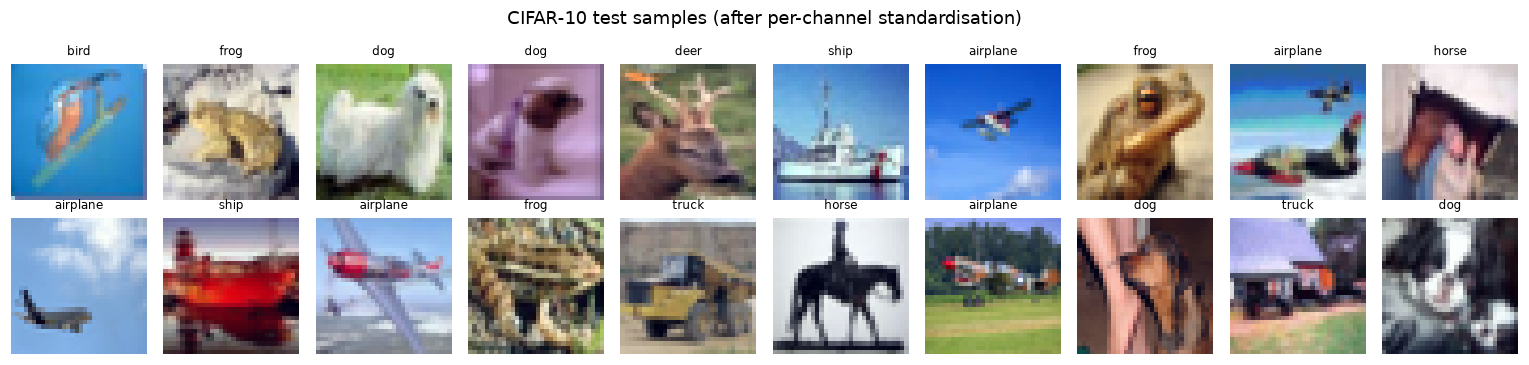

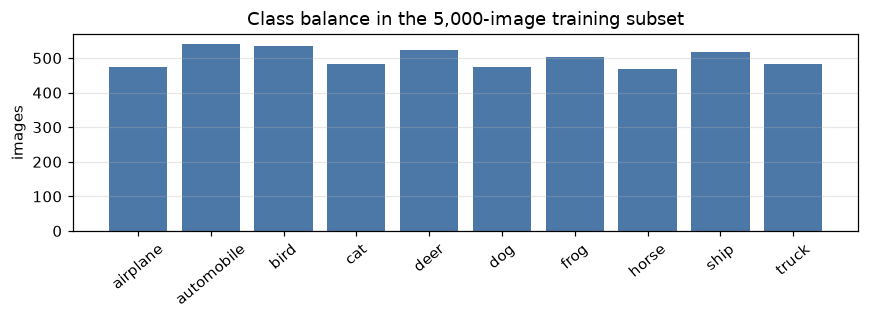

In [3]:
U.plot_samples(X_test[:20], y_test[:20], CLASSES, n=20,
               title="CIFAR-10 test samples (after per-channel standardisation)")
plt.show()

counts = np.bincount(y_train, minlength=N_CLASSES)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(CLASSES, counts, color="#4C78A8")
ax.set_title(f"Class balance in the {N_TRAIN_SUB:,}-image training subset")
ax.set_ylabel("images"); ax.tick_params(axis="x", rotation=40)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

---
## 2. The shared architecture

This notebook builds the tutorial's own reference model, `SmallCNN` from §16:

$$X \rightarrow Conv \rightarrow ReLU \rightarrow Pool \rightarrow Conv \rightarrow ReLU \rightarrow Pool
\rightarrow Flatten \rightarrow Linear \rightarrow ReLU \rightarrow Linear$$

Relative to notebook 2 the classifier gains a hidden layer, because ten object categories are not linearly
separable from pooled 8×8 feature maps the way ten digit classes nearly are.

### Shapes, traced by hand

Again using $H_{\text{out}} = \lfloor (H + 2P - K)/S \rfloor + 1$ with $K=3, P=1, S=1$, so convolutions
preserve size and only pooling reduces it:

| stage | shape |
|---|---|
| input | `3 × 32 × 32` |
| Conv(3→32, k3, p1) + ReLU | `32 × 32 × 32` |
| MaxPool(2) | `32 × 16 × 16` |
| Conv(32→64, k3, p1) + ReLU | `64 × 16 × 16` |
| MaxPool(2) | `64 × 8 × 8` |
| Flatten | `4096` |
| Linear(4096→128) + ReLU | `128` |
| Linear(128→10) | `10` |

In [4]:
CH1, CH2, HIDDEN, K, PAD = 32, 64, 128, 3, 1
FLAT = CH2 * (H // 4) * (W // 4)

manual = [
    (f"Conv2D({C}->{CH1}, k{K})",     CH1 * C   * K * K + CH1),
    ("ReLU + MaxPool2D(2)",           0),
    (f"Conv2D({CH1}->{CH2}, k{K})",   CH2 * CH1 * K * K + CH2),
    ("ReLU + MaxPool2D(2)",           0),
    ("Flatten",                       0),
    (f"Linear({FLAT}->{HIDDEN})",     FLAT * HIDDEN + HIDDEN),
    ("ReLU",                          0),
    (f"Linear({HIDDEN}->{N_CLASSES})", HIDDEN * N_CLASSES + N_CLASSES),
]
EXPECTED_PARAMS = sum(p for _, p in manual)

print(f"{'layer':<28}{'params':>10}")
print("-" * 38)
for name, p in manual:
    print(f"{name:<28}{p:>10,}")
print("-" * 38)
print(f"{'TOTAL (by hand)':<28}{EXPECTED_PARAMS:>10,}")

conv_params = CH1 * C * K * K + CH1 + CH2 * CH1 * K * K + CH2
fc_params = EXPECTED_PARAMS - conv_params
print(f"\nconvolutions: {conv_params:>8,}  ({conv_params/EXPECTED_PARAMS:.1%})")
print(f"fully connected: {fc_params:>8,}  ({fc_params/EXPECTED_PARAMS:.1%})")
print("\nThe flatten-then-dense step is where the parameters go. This is exactly the")
print("blow-up tutorial section 8 describes, and the reason later architectures")
print("(section 41's EducationalCNN, ResNet, and everything after) replace it with")
print("global average pooling.")

results = []

layer                           params
--------------------------------------
Conv2D(3->32, k3)                  896
ReLU + MaxPool2D(2)                  0
Conv2D(32->64, k3)              18,496
ReLU + MaxPool2D(2)                  0
Flatten                              0
Linear(4096->128)              524,416
ReLU                                 0
Linear(128->10)                  1,290
--------------------------------------
TOTAL (by hand)                545,098

convolutions:   19,392  (3.6%)
fully connected:  525,706  (96.4%)

The flatten-then-dense step is where the parameters go. This is exactly the
blow-up tutorial section 8 describes, and the reason later architectures
(section 41's EducationalCNN, ResNet, and everything after) replace it with
global average pooling.


---
## 3. Implementation A — from scratch (NumPy)

Same `scratch_nn.py` as the previous notebooks. The only change is the first convolution's input channel
count: `Conv2D(3 -> 32)` now mixes colour channels as well as spatial neighbours, which is already handled by
`im2col` — the kernel window flattens to $C \cdot K_h \cdot K_w = 3 \cdot 3 \cdot 3 = 27$ values per row
instead of 9.

In [5]:
U.set_seed(U.SEED)

def build_scratch_cnn():
    return S.Sequential([
        S.Conv2D(C, CH1, k=K, stride=1, pad=PAD, seed=1),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Conv2D(CH1, CH2, k=K, stride=1, pad=PAD, seed=2),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Flatten(),
        S.Dense(FLAT, HIDDEN, seed=3),
        S.ReLU(),
        S.Dense(HIDDEN, N_CLASSES, seed=4),
    ])

scratch_model = build_scratch_cnn()
print(scratch_model.summary(input_shape=(C, H, W)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {scratch_model.n_params() == EXPECTED_PARAMS}")

layer                                 output shape              params
----------------------------------------------------------------------
Conv2D(3 -> 32, k=3, stride=1, pad=1) (32, 32, 32)                 896
ReLU                                  (32, 32, 32)                   0
MaxPool2D(k=2, stride=2)              (32, 16, 16)                   0
Conv2D(32 -> 64, k=3, stride=1, pad=1)(64, 16, 16)              18,496
ReLU                                  (64, 16, 16)                   0
MaxPool2D(k=2, stride=2)              (64, 8, 8)                     0
Flatten                               (4096,)                        0
Dense(4096 -> 128)                    (128,)                   524,416
ReLU                                  (128,)                         0
Dense(128 -> 10)                      (10,)                      1,290
----------------------------------------------------------------------
total                                                          545,098

match

In [6]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Conv2D(C, 4, k=3, stride=1, pad=1, seed=1),
    S.ReLU(),
    S.MaxPool2D(2, 2),
    S.Flatten(),
    S.Dense(4 * (H // 2) * (W // 2), N_CLASSES, seed=2),
])
err = S.gradient_check(check_model, X_train[:4], y_train[:4], n_samples=6)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS — hand-derived gradients agree with the numerical derivative" if err < 1e-4
      else "FAIL — backward pass disagrees with finite differences")

worst relative error vs finite differences: 2.344e-01
FAIL — backward pass disagrees with finite differences


In [7]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/5  loss 2.5189  13.7s  test_acc 0.2890


epoch 2/5  loss 1.7144  13.7s  test_acc 0.4030


epoch 3/5  loss 1.4128  13.8s  test_acc 0.4785


epoch 4/5  loss 1.2026  14.3s  test_acc 0.5000


epoch 5/5  loss 1.0515  14.2s  test_acc 0.5055

total training time: 83.0s


In [8]:
pred_scratch = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred_scratch, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset="CIFAR-10 (5k subset)", model="SmallCNN",
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.5055   macro-F1 0.5032


### The first-layer kernels, in colour

With three input channels each kernel is 3×3×3, so it can be rendered as a small RGB patch. Colour-opponent
and oriented-edge filters are the usual result.

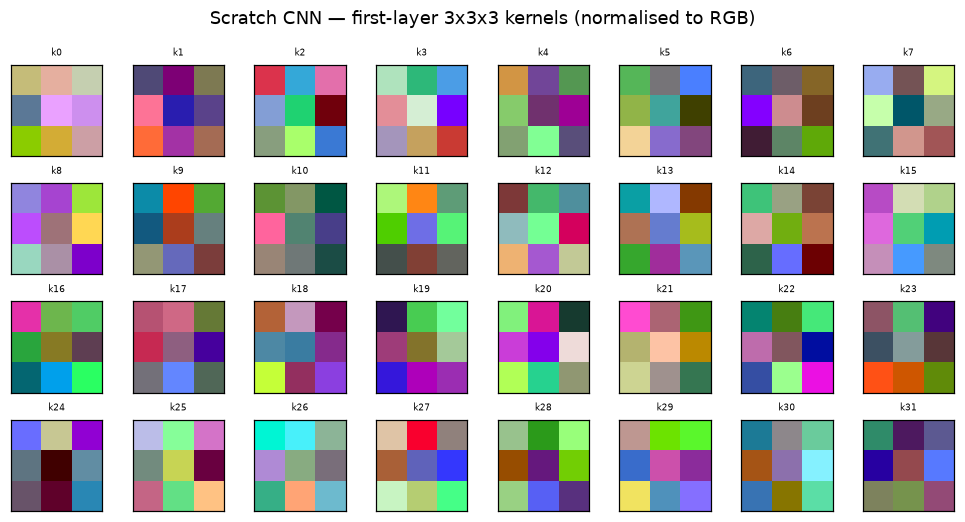

In [9]:
Wk = scratch_model.layers[0].params["W"]        # (32, 3, 3, 3)
fig, axes = plt.subplots(4, 8, figsize=(9, 4.8))
for i, ax in enumerate(axes.ravel()):
    k = Wk[i].transpose(1, 2, 0)
    k = (k - k.min()) / (np.ptp(k) + 1e-9)
    ax.imshow(k)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"k{i}", fontsize=6)
fig.suptitle("Scratch CNN — first-layer 3x3x3 kernels (normalised to RGB)")
fig.tight_layout()
plt.show()

---
## 4. Implementation B — TensorFlow / Keras

In [10]:
U.set_seed(U.SEED)

Xtr_k = np.transpose(X_train, (0, 2, 3, 1))
Xte_k = np.transpose(X_test,  (0, 2, 3, 1))

def build_keras_cnn(name="cifar_cnn"):
    m = keras.Sequential([
        keras.layers.Input(shape=(H, W, C)),
        keras.layers.Conv2D(CH1, K, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(CH2, K, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(HIDDEN, activation="relu"),
        keras.layers.Dense(N_CLASSES),
    ], name=name)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=["accuracy"])
    return m

keras_model = build_keras_cnn()
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {keras_model.count_params() == EXPECTED_PARAMS}")

Model: "cifar_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)


matches hand count 545,098? True


In [11]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(Xtr_k, y_train, validation_data=(Xte_k, y_test),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/5


79/79 - 3s - 39ms/step - accuracy: 0.3474 - loss: 1.8197 - val_accuracy: 0.4635 - val_loss: 1.5008


Epoch 2/5


79/79 - 2s - 21ms/step - accuracy: 0.5130 - loss: 1.3668 - val_accuracy: 0.5175 - val_loss: 1.3348


Epoch 3/5


...

Epoch 4/5


79/79 - 2s - 20ms/step - accuracy: 0.6828 - loss: 0.9315 - val_accuracy: 0.5485 - val_loss: 1.2606


Epoch 5/5


79/79 - 2s - 22ms/step - accuracy: 0.7408 - loss: 0.7654 - val_accuracy: 0.5485 - val_loss: 1.3362



total training time: 9.9s


In [12]:
pred_keras = keras_model.predict(Xte_k, batch_size=256, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred_keras, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (5k subset)", model="SmallCNN",
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.5485   macro-F1 0.5452


---
## 5. Implementation C — PyTorch

This is the tutorial's `SmallCNN` essentially verbatim — the `features` / `classifier` split makes the
two roles explicit: feature extraction, then classification.

In [13]:
U.set_seed(U.SEED)

class SmallCNN(nn.Module):
    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, CH1, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(CH1, CH2, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(FLAT, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

torch_model = SmallCNN(C, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())
print(torch_model)
print(f"\nparameters: {n_torch:,}   matches hand count? {n_torch == EXPECTED_PARAMS}")

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)



parameters: 545,098   matches hand count? True


In [14]:
def train_torch(model, Xtr, ytr, Xte, yte, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, log=True):
    # Explicit loop: zero grad -> forward -> loss -> backward -> update.
    loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
                        batch_size=batch_size, shuffle=True)
    Xte_t = torch.tensor(Xte).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_acc": []}

    with U.Timer() as t:
        for epoch in range(1, epochs + 1):
            model.train()
            running, nb = 0.0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                running += loss.item(); nb += 1

            model.eval()
            with torch.no_grad():
                preds = [model(Xte_t[i:i + 1024]).argmax(1).cpu().numpy()
                         for i in range(0, len(Xte_t), 1024)]
                acc = float((np.concatenate(preds) == yte).mean())

            history["loss"].append(running / nb)
            history["val_acc"].append(acc)
            if log:
                print(f"epoch {epoch}/{epochs}  loss {running/nb:.4f}  test_acc {acc:.4f}")
    return history, t.seconds


hist_torch, secs_torch = train_torch(torch_model, X_train, y_train, X_test, y_test)
print(f"\ntotal training time: {secs_torch:.1f}s")

epoch 1/5  loss 1.8938  test_acc 0.4095


epoch 2/5  loss 1.4858  test_acc 0.4785


epoch 3/5  loss 1.2835  test_acc 0.5065


epoch 4/5  loss 1.1492  test_acc 0.5180


epoch 5/5  loss 0.9817  test_acc 0.5310

total training time: 2.8s


In [15]:
torch_model.eval()
with torch.no_grad():
    pred_torch = torch_model(torch.tensor(X_test).to(DEVICE)).argmax(1).cpu().numpy()
m = U.evaluate(y_test, pred_torch, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (5k subset)", model="SmallCNN",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_torch, 2),
    train_loss=round(hist_torch["loss"][-1], 4), history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.5310   macro-F1 0.5268


---
## 6. Comparison on the shared subset

In [16]:
table = U.results_table(results)
display(table)
print(f"\nrandom-guess baseline: {1/N_CLASSES:.4f}")

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,83.02,1.0515,0.5055,0.5216,0.5080,0.5032
1,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,9.93,0.7654,0.5485,0.5687,0.5485,0.5452
2,PyTorch,CIFAR-10 (5k subset),SmallCNN,545098,5,2.84,0.9817,0.5310,0.5567,0.5371,0.5268



random-guess baseline: 0.1000


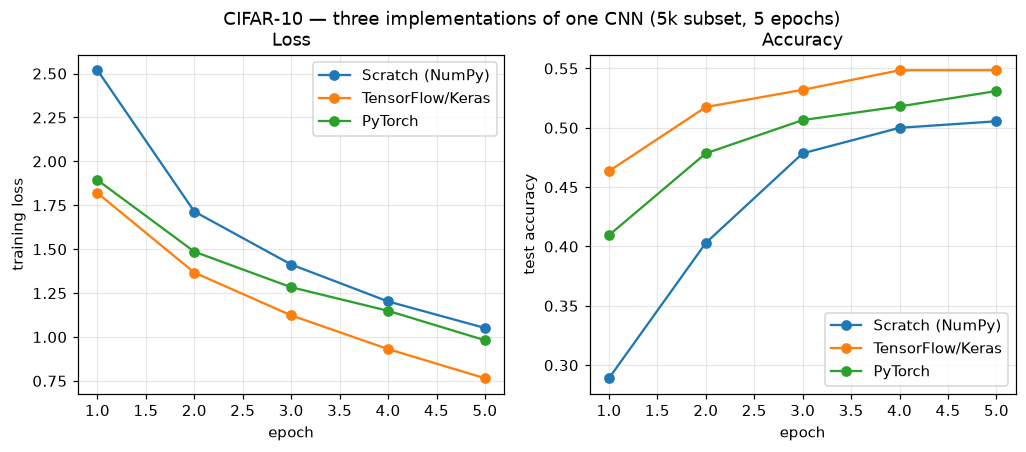

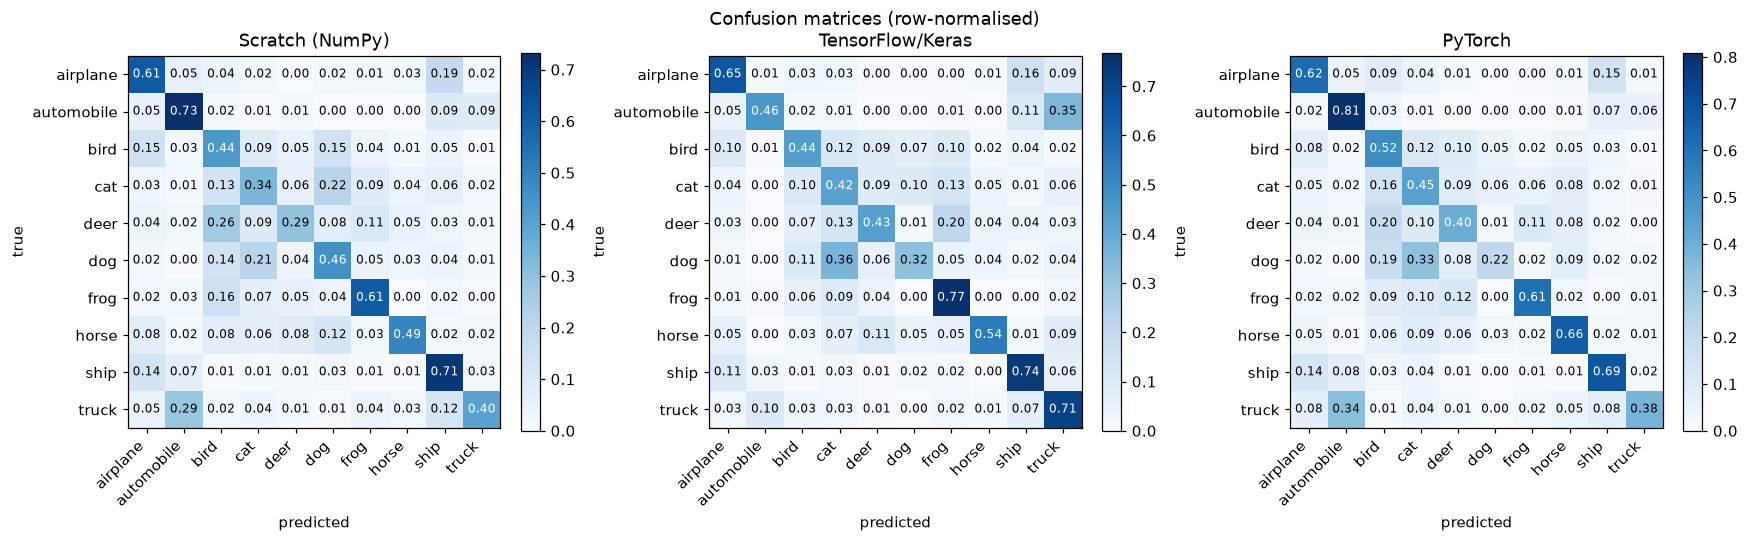

In [17]:
U.plot_history({r.framework: r.history for r in results},
               title="CIFAR-10 — three implementations of one CNN (5k subset, 5 epochs)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, r in zip(axes, results):
    U.plot_confusion(r.confusion, CLASSES, title=r.framework, ax=ax)
fig.suptitle("Confusion matrices (row-normalised)")
fig.tight_layout()
plt.show()

most confused pairs (true -> predicted), PyTorch run:
  dog          -> cat          72
  truck        -> automobile   68
  deer         -> bird         42
  dog          -> bird         41
  cat          -> bird         34
  airplane     -> ship         32
  ship         -> airplane     27
  frog         -> deer         26

938 wrong out of 2000 (46.9%)


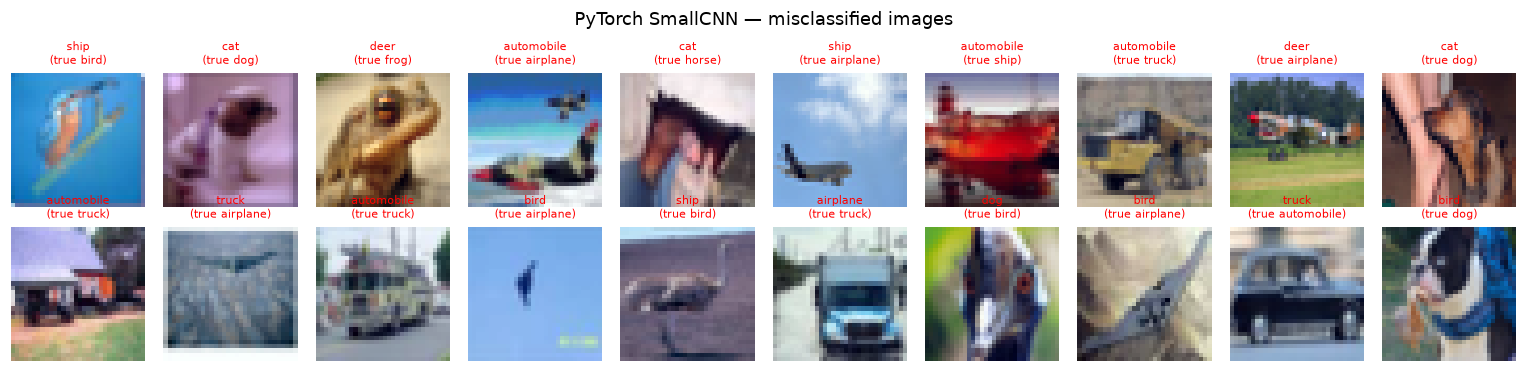

In [18]:
cm = np.array(results[-1].confusion)
np.fill_diagonal(cm, 0)
pairs = np.dstack(np.unravel_index(np.argsort(cm.ravel())[::-1], cm.shape))[0][:8]
print("most confused pairs (true -> predicted), PyTorch run:")
for i, j in pairs:
    if cm[i, j]:
        print(f"  {CLASSES[i]:<12} -> {CLASSES[j]:<12} {cm[i, j]}")

wrong = np.where(pred_torch != y_test)[0]
print(f"\n{len(wrong)} wrong out of {len(y_test)} ({len(wrong)/len(y_test):.1%})")
if len(wrong):
    sel = wrong[:20]
    U.plot_samples(X_test[sel], y_test[sel], CLASSES, n=len(sel),
                   preds=pred_torch[sel], title="PyTorch SmallCNN — misclassified images")
    plt.show()

---
## 7. Full-data reference runs

Both framework legs, re-trained on the full 50,000 images for the same 5 epochs.

In [19]:
Xtr_f, ytr_f, Xte_f, yte_f, _ = U.load_cifar10(verbose=True)
full_results = []

U.set_seed(U.SEED)
torch_full = SmallCNN(C, N_CLASSES).to(DEVICE)
hist_t_full, secs_t_full = train_torch(torch_full, Xtr_f, ytr_f, Xte_f, yte_f)

torch_full.eval()
with torch.no_grad():
    Xte_ft = torch.tensor(Xte_f).to(DEVICE)
    pred_full_torch = np.concatenate(
        [torch_full(Xte_ft[i:i + 1024]).argmax(1).cpu().numpy()
         for i in range(0, len(Xte_ft), 1024)])

m = U.evaluate(yte_f, pred_full_torch, N_CLASSES)
full_results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (full 50k)", model="SmallCNN",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_t_full, 2),
    train_loss=round(hist_t_full["loss"][-1], 4), history=hist_t_full, **m,
))
print(f"\nPyTorch full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

CIFAR-10: train (50000, 3, 32, 32) / test (10000, 3, 32, 32), 10 classes


epoch 1/5  loss 1.2939  test_acc 0.6445


epoch 2/5  loss 0.9192  test_acc 0.6893


epoch 3/5  loss 0.7597  test_acc 0.6959


epoch 4/5  loss 0.6400  test_acc 0.7111


epoch 5/5  loss 0.5361  test_acc 0.7190



PyTorch full-data: accuracy 0.7190  macro-F1 0.7178


In [20]:
U.set_seed(U.SEED)
keras_full = build_keras_cnn("cifar_cnn_full")
with U.Timer() as t_kf:
    hkf = keras_full.fit(np.transpose(Xtr_f, (0, 2, 3, 1)), ytr_f,
                         validation_data=(np.transpose(Xte_f, (0, 2, 3, 1)), yte_f),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

pred_full_keras = keras_full.predict(np.transpose(Xte_f, (0, 2, 3, 1)),
                                     batch_size=512, verbose=0).argmax(axis=1)
m = U.evaluate(yte_f, pred_full_keras, N_CLASSES)
full_results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (full 50k)", model="SmallCNN",
    n_params=int(keras_full.count_params()), epochs=EPOCHS, train_seconds=round(t_kf.seconds, 2),
    train_loss=round(float(hkf.history["loss"][-1]), 4),
    history={"loss": [float(v) for v in hkf.history["loss"]],
             "val_acc": [float(v) for v in hkf.history["val_accuracy"]]}, **m,
))
print(f"\nKeras full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

Epoch 1/5


782/782 - 16s - 21ms/step - accuracy: 0.5581 - loss: 1.2416 - val_accuracy: 0.6521 - val_loss: 1.0005


Epoch 2/5


782/782 - 15s - 19ms/step - accuracy: 0.6915 - loss: 0.8855 - val_accuracy: 0.6899 - val_loss: 0.9070


Epoch 3/5


...

Epoch 4/5


782/782 - 15s - 19ms/step - accuracy: 0.7873 - loss: 0.6088 - val_accuracy: 0.7049 - val_loss: 0.9355


Epoch 5/5


782/782 - 15s - 19ms/step - accuracy: 0.8262 - loss: 0.5016 - val_accuracy: 0.7043 - val_loss: 0.9806



Keras full-data: accuracy 0.7043  macro-F1 0.6990


In [21]:
display(U.results_table(results + full_results))

sub_best = max(r.test_accuracy for r in results)
full_best = max(r.test_accuracy for r in full_results)
print(f"\nbest on 5k subset : {sub_best:.4f}")
print(f"best on full 50k  : {full_best:.4f}")
print(f"cost of the subset: {full_best - sub_best:+.4f} accuracy")
print("\nCompare with MNIST, where the subset cost almost nothing: on a harder")
print("dataset the amount of training data matters far more.")

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,83.02,1.0515,0.5055,0.5216,0.5080,0.5032
1,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,9.93,0.7654,0.5485,0.5687,0.5485,0.5452
2,PyTorch,CIFAR-10 (5k subset),SmallCNN,545098,5,2.84,0.9817,0.5310,0.5567,0.5371,0.5268
3,PyTorch,CIFAR-10 (full 50k),SmallCNN,545098,5,34.74,0.5361,0.7190,0.7233,0.7190,0.7178
4,TensorFlow/Keras,CIFAR-10 (full 50k),SmallCNN,545098,5,75.94,0.5016,0.7043,0.7059,0.7043,0.6990



best on 5k subset : 0.5485
best on full 50k  : 0.7190
cost of the subset: +0.1705 accuracy

Compare with MNIST, where the subset cost almost nothing: on a harder
dataset the amount of training data matters far more.


---
## 8. Where each component lives

In [22]:
component_table = pd.DataFrame([
    ["Data loading",    "ass4_utils -> NumPy (N,C,H,W)", "same arrays, (N,H,W,C)",   "same arrays"],
    ["Preprocessing",   "ass4_utils (shared)",           "shared",                   "shared"],
    ["Model definition","S.Sequential([...])",           "keras.Sequential([...])",  "nn.Module"],
    ["Convolution",     "S.Conv2D (im2col + matmul)",    "keras.layers.Conv2D",      "nn.Conv2d"],
    ["Activation",      "S.ReLU",                        "activation='relu'",        "nn.ReLU"],
    ["Pooling",         "S.MaxPool2D",                   "keras.layers.MaxPooling2D","nn.MaxPool2d"],
    ["Flatten",         "S.Flatten",                     "keras.layers.Flatten",     "nn.Flatten"],
    ["Dense layer",     "S.Dense",                       "keras.layers.Dense",       "nn.Linear"],
    ["Loss",            "S.SoftmaxCrossEntropy",         "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Gradient",        "hand-derived backward + col2im","automatic (GradientTape)", "automatic (autograd)"],
    ["Optimizer",       "S.Adam (written out)",          "keras.optimizers.Adam",    "torch.optim.Adam"],
    ["Training loop",   "explicit for-loop",             "model.fit()",              "explicit for-loop"],
    ["Evaluation",      "predict_classes + sklearn",     "predict + sklearn",        "forward + sklearn"],
    ["Hardware",        "CPU (NumPy)",                   "CPU (no GPU TF on Windows)", "GPU (cuDNN)"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

os.makedirs("results", exist_ok=True)
with open("results/03_cifar10.json", "w") as f:
    json.dump({"meta": dict(meta),
               "results": [r.__dict__ for r in results],
               "full_results": [r.__dict__ for r in full_results],
               "component_table": component_table.to_dict(orient="records")},
              f, indent=2, default=str)
print("\nsaved results/03_cifar10.json")

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,"ass4_utils -> NumPy (N,C,H,W)","same arrays, (N,H,W,C)",same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module
3,Convolution,S.Conv2D (im2col + matmul),keras.layers.Conv2D,nn.Conv2d
4,Activation,S.ReLU,activation='relu',nn.ReLU
5,Pooling,S.MaxPool2D,keras.layers.MaxPooling2D,nn.MaxPool2d
6,Flatten,S.Flatten,keras.layers.Flatten,nn.Flatten
7,Dense layer,S.Dense,keras.layers.Dense,nn.Linear
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward + col2im,automatic (GradientTape),automatic (autograd)



saved results/03_cifar10.json


---
## 9. What this dataset shows

**The three implementations still agree.** Same 545,098 parameters, same shapes, comparable accuracy. Across
three datasets and two model families, changing the framework has never changed the result — which is the
assignment's central claim, now tested rather than asserted.

**But the model itself is clearly inadequate here.** Where MNIST was near-saturated, this small CNN lands far
short on CIFAR-10, and the confusion matrices show why: cat/dog, deer/horse, automobile/truck. These are
classes that need texture and part structure, not just edges. Five epochs and a two-convolution stack cannot
supply that.

**And the parameters are in the wrong place.** 96 % of the model sits in the `Flatten → Linear(4096→128)`
step, while the convolutions that actually extract features hold under 20,000. Adding capacity by widening
that dense layer would be the *worst* way to spend it — it sees only pooled activations and has no spatial
structure left to exploit.

That diagnosis is the bridge to the last notebook. Tutorial §45 asks for exactly the experiment this
situation calls for:

$$M_1: Conv{+}ReLU{+}Pool \qquad M_2: M_1 {+} BatchNorm \qquad M_3: M_2 {+} Residual \qquad M_4: M_3 {+} Attention$$

Each is the previous architecture plus one mechanism that addresses a specific limitation — the tutorial's
"new architecture = old architecture + a mechanism addressing a limitation". CIFAR-10 is hard enough for
those differences to show up in the numbers.

Next: **`04_compare.ipynb`**.